# 06 - Exploratory Data Analysis & Research Questions

This notebook performs EDA and answers all 4 research questions:
- RQ1: Do adverse weather conditions significantly increase flight delay times?
- RQ2: How accurately do airlines report weather as the cause of delays?
- RQ3: Which airports show the strongest relationship between weather and delays?
- RQ4: Can actual weather measurements predict delays better than airline-reported flags?

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Load integrated dataset
integrated_df = pd.read_csv('/content/drive/MyDrive/DM_Project/Data/Integrated/flights_weather_integrated.csv')
integrated_df['FL_DATE'] = pd.to_datetime(integrated_df['FL_DATE'])

print("Dataset loaded:", integrated_df.shape)
print(integrated_df[['DEP_DELAY', 'precipitation_mm', 'windspeed_max_kmh', 'temperature_max']].describe().round(2))

Dataset loaded: (84356, 35)
       DEP_DELAY  precipitation_mm  windspeed_max_kmh  temperature_max
count   84356.00          84356.00           84356.00         84356.00
mean       15.32              2.91              19.85            29.36
std        42.10              6.43               6.30             6.30
min       -29.00              0.00               7.10            11.90
25%        -4.00              0.00              15.20            25.00
50%         0.00              0.00              19.00            29.50
75%        15.00              2.30              23.90            33.20
max       600.00             58.70              50.10            46.60


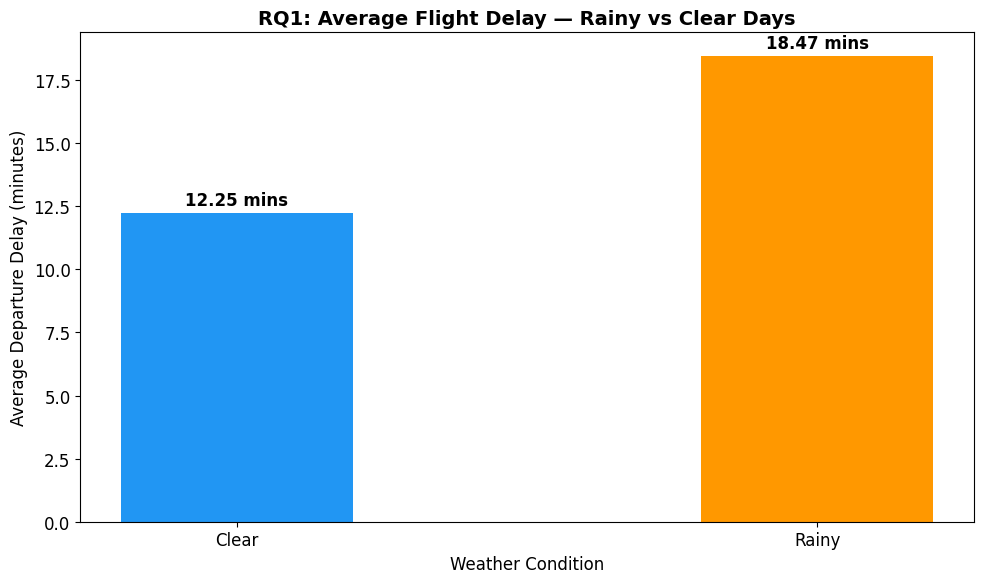

RQ1: Rainy days cause more delays than clear days
Rainy: 18.47 mins
Clear: 12.25 mins


In [4]:
# Prepare data
integrated_df['weather_type'] = integrated_df['precipitation_mm'].apply(
    lambda x: 'Rainy' if x > 0 else 'Clear'
)

rq1 = integrated_df.groupby('weather_type')['DEP_DELAY'].mean().round(2).reset_index()
rq1.columns = ['weather_type', 'avg_delay']

# Chart
fig, ax = plt.subplots()
colors = ['#2196F3', '#FF9800']
bars = ax.bar(rq1['weather_type'], rq1['avg_delay'], color=colors, width=0.4)
ax.set_title('RQ1: Average Flight Delay — Rainy vs Clear Days', fontsize=14, fontweight='bold')
ax.set_xlabel('Weather Condition')
ax.set_ylabel('Average Departure Delay (minutes)')
for bar, val in zip(bars, rq1['avg_delay']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val} mins', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DM_Project/Data/chart1_RQ1_rainy_vs_clear.png', dpi=150)
plt.show()
print("RQ1: Rainy days cause more delays than clear days")
print(f"Rainy: {rq1[rq1['weather_type']=='Rainy']['avg_delay'].values[0]} mins")
print(f"Clear: {rq1[rq1['weather_type']=='Clear']['avg_delay'].values[0]} mins")

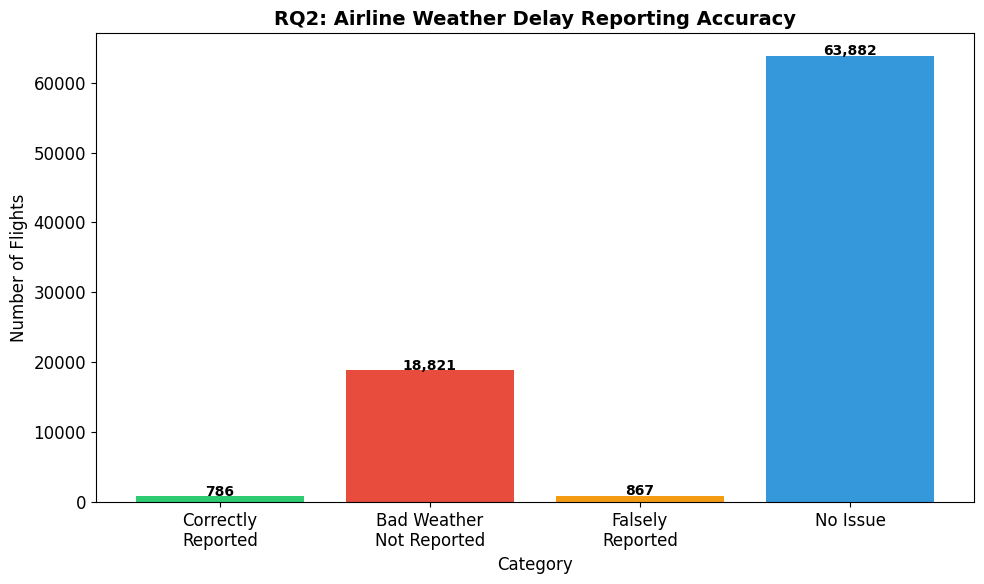

RQ2: Airlines correctly reported only 4.01% of bad weather delays


In [5]:
# Flag actual bad weather
integrated_df['actual_bad_weather'] = (
    (integrated_df['precipitation_mm'] > 5) |
    (integrated_df['windspeed_max_kmh'] > 30)
).astype(int)
integrated_df['airline_reported_weather'] = (integrated_df['DELAY_DUE_WEATHER'] > 0).astype(int)

both = ((integrated_df['actual_bad_weather'] == 1) & (integrated_df['airline_reported_weather'] == 1)).sum()
only_actual = ((integrated_df['actual_bad_weather'] == 1) & (integrated_df['airline_reported_weather'] == 0)).sum()
only_reported = ((integrated_df['actual_bad_weather'] == 0) & (integrated_df['airline_reported_weather'] == 1)).sum()
neither = ((integrated_df['actual_bad_weather'] == 0) & (integrated_df['airline_reported_weather'] == 0)).sum()

# Chart
fig, ax = plt.subplots()
categories = ['Correctly\nReported', 'Bad Weather\nNot Reported', 'Falsely\nReported', 'No Issue']
values = [both, only_actual, only_reported, neither]
colors = ['#2ecc71', '#e74c3c', '#f39c12', '#3498db']
bars = ax.bar(categories, values, color=colors)
ax.set_title('RQ2: Airline Weather Delay Reporting Accuracy', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Number of Flights')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,}', ha='center', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DM_Project/Data/chart2_RQ2_reporting_accuracy.png', dpi=150)
plt.show()
accuracy = round(both / (both + only_actual) * 100, 2)
print(f"RQ2: Airlines correctly reported only {accuracy}% of bad weather delays")

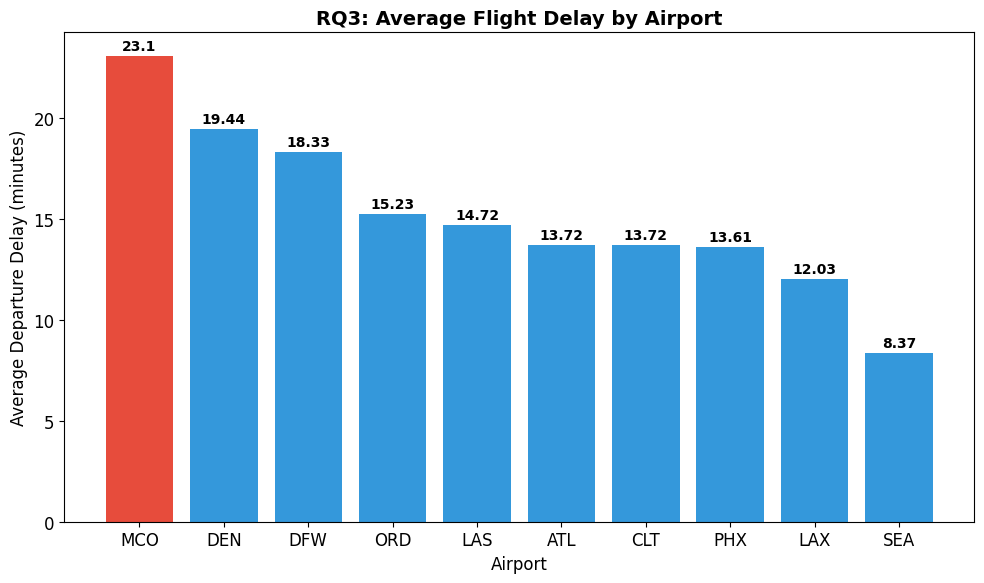

RQ3 answered!
  ORIGIN  avg_delay  avg_precipitation
6    MCO      23.10               8.90
2    DEN      19.44               1.97
3    DFW      18.33               3.86
7    ORD      15.23               3.68
4    LAS      14.72               0.13
0    ATL      13.72               4.71
1    CLT      13.72               2.64
8    PHX      13.61               0.07
5    LAX      12.03               0.08
9    SEA       8.37               2.02


In [6]:
rq3 = integrated_df.groupby('ORIGIN').agg(
    avg_delay=('DEP_DELAY', 'mean'),
    avg_precipitation=('precipitation_mm', 'mean'),
    total_flights=('DEP_DELAY', 'count')
).round(2).reset_index().sort_values('avg_delay', ascending=False)

# Chart
fig, ax = plt.subplots()
colors = ['#e74c3c' if x == rq3['avg_delay'].max() else '#3498db' for x in rq3['avg_delay']]
bars = ax.bar(rq3['ORIGIN'], rq3['avg_delay'], color=colors)
ax.set_title('RQ3: Average Flight Delay by Airport', fontsize=14, fontweight='bold')
ax.set_xlabel('Airport')
ax.set_ylabel('Average Departure Delay (minutes)')
for bar, val in zip(bars, rq3['avg_delay']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DM_Project/Data/chart3_RQ3_delay_by_airport.png', dpi=150)
plt.show()
print("RQ3 answered!")
print(rq3[['ORIGIN', 'avg_delay', 'avg_precipitation']])

=== MODEL COMPARISON ===
Model 1 (Airline Reported): R² = 0.0740, RMSE = 40.44
Model 2 (Actual Weather):   R² = 0.0129, RMSE = 41.75


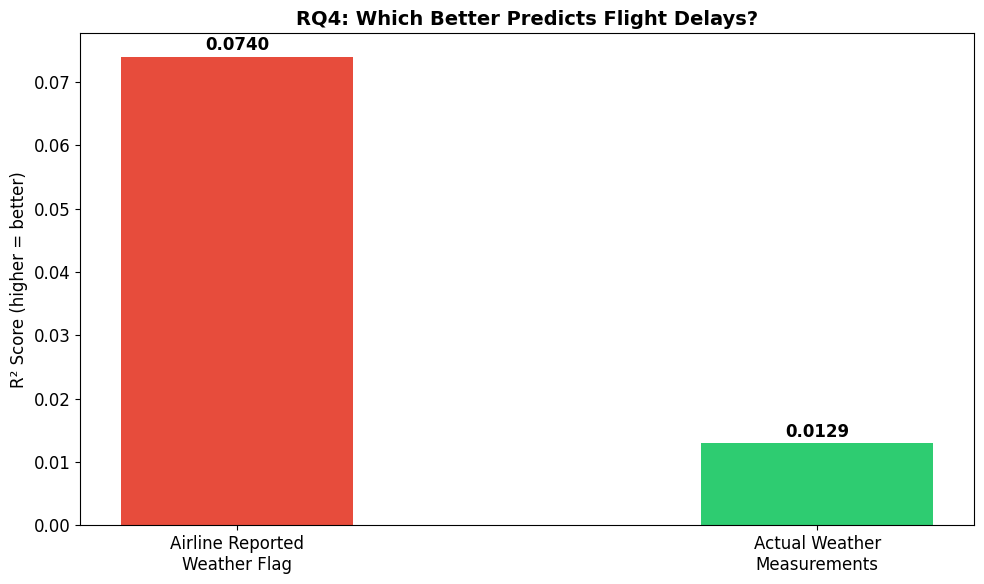

In [8]:
y = integrated_df['DEP_DELAY']

# Model 1 - Airline reported flag
X1 = integrated_df[['DELAY_DUE_WEATHER']]
X1_train, X1_test, y_train, y_test = train_test_split(X1, y, test_size=0.2, random_state=42)
model1 = LinearRegression()
model1.fit(X1_train, y_train)
r2_1 = r2_score(y_test, model1.predict(X1_test))
rmse1 = np.sqrt(mean_squared_error(y_test, model1.predict(X1_test)))

# Model 2 - Actual weather
X2 = integrated_df[['precipitation_mm', 'windspeed_max_kmh', 'temperature_max']]
X2_train, X2_test, _, _ = train_test_split(X2, y, test_size=0.2, random_state=42)
model2 = LinearRegression()
model2.fit(X2_train, y_train)
r2_2 = r2_score(y_test, model2.predict(X2_test))
rmse2 = np.sqrt(mean_squared_error(y_test, model2.predict(X2_test)))

print("=== MODEL COMPARISON ===")
print(f"Model 1 (Airline Reported): R² = {r2_1:.4f}, RMSE = {rmse1:.2f}")
print(f"Model 2 (Actual Weather):   R² = {r2_2:.4f}, RMSE = {rmse2:.2f}")

# Chart
fig, ax = plt.subplots()
models = ['Airline Reported\nWeather Flag', 'Actual Weather\nMeasurements']
r2_scores = [r2_1, r2_2]
colors = ['#e74c3c', '#2ecc71']
bars = ax.bar(models, r2_scores, color=colors, width=0.4)
ax.set_title('RQ4: Which Better Predicts Flight Delays?', fontsize=14, fontweight='bold')
ax.set_ylabel('R² Score (higher = better)')
for bar, val in zip(bars, r2_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DM_Project/Data/chart4_RQ4_model_comparison.png', dpi=150)
plt.show()


In [10]:
print("=" * 50)
print("RESEARCH QUESTIONS SUMMARY")
print("=" * 50)
print(f"RQ1: Rainy days have {round((rq1[rq1['weather_type']=='Rainy']['avg_delay'].values[0] / rq1[rq1['weather_type']=='Clear']['avg_delay'].values[0] - 1) * 100, 1)}% higher delays than clear days")
print(f"RQ2: Airlines correctly reported only {accuracy}% of bad weather delays")
print(f"RQ3: Worst airport: {rq3.iloc[0]['ORIGIN']} ({rq3.iloc[0]['avg_delay']} mins avg delay)")
print(f"     Best airport:  {rq3.iloc[-1]['ORIGIN']} ({rq3.iloc[-1]['avg_delay']} mins avg delay)")
print(f"RQ4: Weather explains only {round(max(r2_1, r2_2)*100, 1)}% of delay variance")
print("=" * 50)


RESEARCH QUESTIONS SUMMARY
RQ1: Rainy days have 50.8% higher delays than clear days
RQ2: Airlines correctly reported only 4.01% of bad weather delays
RQ3: Worst airport: MCO (23.1 mins avg delay)
     Best airport:  SEA (8.37 mins avg delay)
RQ4: Weather explains only 7.4% of delay variance
